# Hour 4: Deep Learning Foundations: Perceptron & Activation Functions

In this notebook, we will:
1. Build a `Perceptron` from scratch in NumPy.
2. Train it on logical AND and OR gates.
3. Prove its failure on non-linearly separable XOR gate.
4. Implement and plot major activation functions (Sigmoid, Tanh, ReLU, LeakyReLU, GELU).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print('Perceptron & Activations setup complete!')

Perceptron & Activations setup complete!


## Step 1: Perceptron Class Implementation from Scratch

In [2]:
class Perceptron:
    def __init__(self, input_dim, lr=0.1, epochs=100):
        self.weights = np.zeros(input_dim)
        self.bias = 0.0
        self.lr = lr
        self.epochs = epochs
        self.errors = []

    def step_function(self, z):
        return np.where(z >= 0.0, 1, 0)

    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.step_function(z)

    def fit(self, X, y):
        for epoch in range(self.epochs):
            total_error = 0
            for xi, target in zip(X, y):
                pred = self.predict(xi)
                update = self.lr * (target - pred)
                self.weights += update * xi
                self.bias += update
                total_error += int(update != 0.0)
            self.errors.append(total_error)
            if total_error == 0:
                print(f'Converged at epoch {epoch+1}')
                break
        return self

## Step 2: Training on Logic Gates (AND, OR, XOR)

In [3]:
X_logic = np.array([[0,0], [0,1], [1,0], [1,1]])
y_and = np.array([0, 0, 0, 1])
y_or  = np.array([0, 1, 1, 1])
y_xor = np.array([0, 1, 1, 0])

p_and = Perceptron(input_dim=2).fit(X_logic, y_and)
print('AND Predictions:', p_and.predict(X_logic))

p_or = Perceptron(input_dim=2).fit(X_logic, y_or)
print('OR Predictions:', p_or.predict(X_logic))

p_xor = Perceptron(input_dim=2).fit(X_logic, y_xor)
print('XOR Predictions (Failed):', p_xor.predict(X_logic))

Converged at epoch 4
AND Predictions: [0 0 0 1]
Converged at epoch 4
OR Predictions: [0 1 1 1]
XOR Predictions (Failed): [1 1 0 0]


# Task
## Report:
**1. The Core Limitation of Single-Layer PerceptronsA single-layer perceptron classifies data by constructing a linear decision boundary (a straight line in 2D space) defined by $w_1 x_1 + w_2 x_2 + b = 0$.Linearly Separable Logic Gates (AND, OR, NAND):**

 Inputs producing output 0 and output 1 can be completely separated by a single straight line.Non-Linearly Separable Gates (XOR): The XOR gate outputs 1 for opposite inputs $[(0,1), (1,0)]$ and 0 for identical inputs $[(0,0), (1,1)]$. Because identical outputs lie on opposite diagonals of the input space, no single linear decision boundary can separate Class 0 from Class 1.

**2. Mathematical Proof of FailureTo successfully represent XOR, a perceptron must satisfy four simultaneous linear inequalities:**

$(0,0) \to 0 \implies b < 0$

$(0,1) \to 1 \implies w_2 + b \ge 0 \implies w_2 \ge -b > 0$

$(1,0) \to 1 \implies w_1 + b \ge 0 \implies w_1 \ge -b > 0$

$(1,1) \to 0 \implies w_1 + w_2 + b < 0$

Combining conditions (2) and (3) yields $w_1 + w_2 \ge -2b$. Adding $b$ to both sides results in:$$w_1 + w_2 + b \ge -b > 0$$This directly contradicts condition (4), which requires $w_1 + w_2 + b < 0$. Because no combination of weights $(w_1, w_2)$ and bias ($b$) can satisfy all four conditions simultaneously, a single-layer perceptron mathematically cannot implement the XOR function.

**3.Solution: Multi-Layer Perceptrons (MLPs)
Multi-Layer Perceptrons overcome this limitation through two mechanisms:**

  3.1 Feature Space Transformation: Hidden layers with non-linear activation functions (e.g., Sigmoid, ReLU) project non-linear 2D inputs into a higher-dimensional feature space where the targets become linearly separable.

  3.2 Composition of Decision Boundaries: Hidden neurons act as intermediate logic operations (such as combining AND and OR sub-circuits) to form a complex, non-linear decision boundary.

In [4]:
import numpy as np

class MultiLayerPerceptron:
    def __init__(self, input_size=2, hidden_size=2, output_size=1, learning_rate=0.2):
        self.lr = learning_rate
        
        np.random.seed(42)
        self.W1 = np.random.uniform(-1, 1, (input_size, hidden_size))
        self.b1 = np.zeros((1, hidden_size))
        
        self.W2 = np.random.uniform(-1, 1, (hidden_size, output_size))
        self.b2 = np.zeros((1, output_size))

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def _sigmoid_derivative(self, x):
        return x * (1 - x)

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self._sigmoid(self.z1) 
        
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self._sigmoid(self.z2)
        return self.a2

    def backward(self, X, y):
        m = X.shape[0]
        
        error_output = self.a2 - y
        delta_output = error_output * self._sigmoid_derivative(self.a2)
        
        error_hidden = np.dot(delta_output, self.W2.T)
        delta_hidden = error_hidden * self._sigmoid_derivative(self.a1)
        
        self.W2 -= self.lr * np.dot(self.a1.T, delta_output)
        self.b2 -= self.lr * np.sum(delta_output, axis=0, keepdims=True)
        
        self.W1 -= self.lr * np.dot(X.T, delta_hidden)
        self.b1 -= self.lr * np.sum(delta_hidden, axis=0, keepdims=True)

    def fit(self, X, y, epochs=10000):
        y = y.reshape(-1, 1)
        for epoch in range(epochs):
            self.forward(X)
            self.backward(X, y)

    def predict(self, X):
        output = self.forward(X)
        return (output > 0.5).astype(int)


X_logic = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

mlp = MultiLayerPerceptron(input_size=2, hidden_size=2, output_size=1, learning_rate=0.5)
mlp.fit(X_logic, y_xor, epochs=10000)

predictions = mlp.predict(X_logic)
probabilities = mlp.forward(X_logic)

print("XOR Predictions: ")
for i in range(len(X_logic)):
    print(f"{X_logic[i]} Predicted: {predictions[i][0]}")

XOR Predictions: 
[0 0] Predicted: 0
[0 1] Predicted: 1
[1 0] Predicted: 1
[1 1] Predicted: 0


## Step 3: Activation Functions Implementation & Visualization

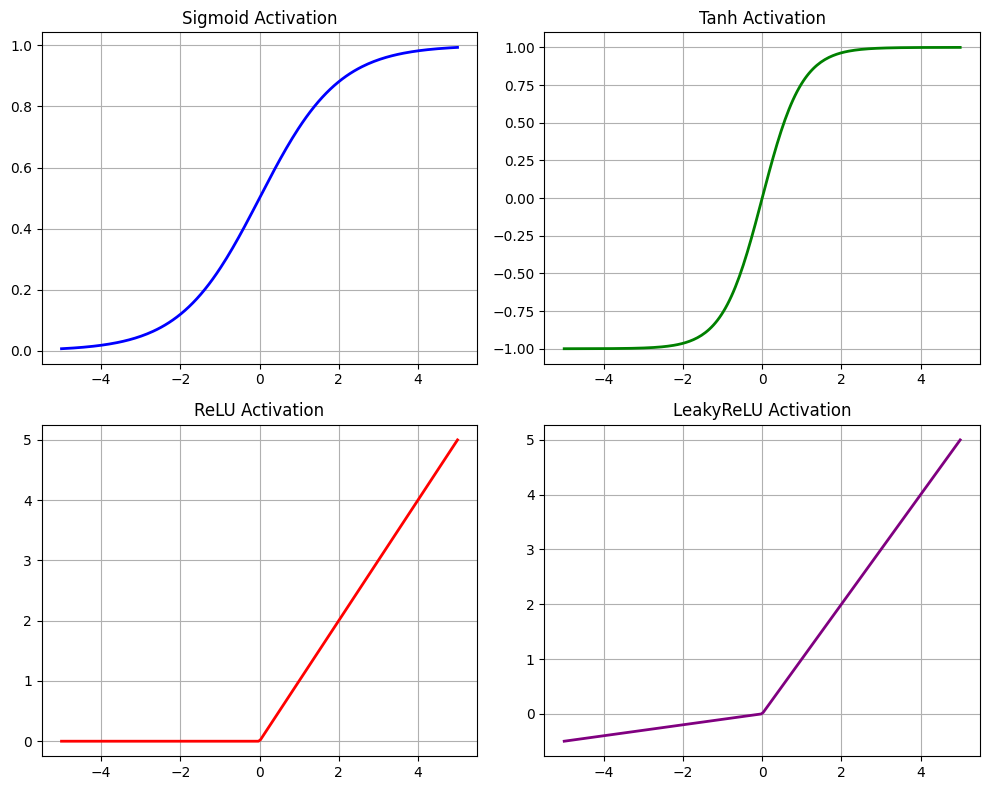

In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0, z)

def leaky_relu(z, alpha=0.1):
    return np.where(z > 0, z, alpha * z)

z = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0,0].plot(z, sigmoid(z), color='blue', lw=2)
axes[0,0].set_title('Sigmoid Activation')
axes[0,0].grid(True)

axes[0,1].plot(z, tanh(z), color='green', lw=2)
axes[0,1].set_title('Tanh Activation')
axes[0,1].grid(True)

axes[1,0].plot(z, relu(z), color='red', lw=2)
axes[1,0].set_title('ReLU Activation')
axes[1,0].grid(True)

axes[1,1].plot(z, leaky_relu(z), color='purple', lw=2)
axes[1,1].set_title('LeakyReLU Activation')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

## Mini-Exercise
**Question:** Why does the derivative of ReLU equal 0 for $z < 0$, and what problem does this create during neural network training?